# Inferencing with Bayesian Networks in Python
## Lung Cancer Diagnosis using Bayesian Network         

### Aim
To construct a Bayesian Network for Lung Cancer diagnosis and perform probabilistic inference using Python.

### Objective
- Build a Bayesian Network using pgmpy.
- Define Conditional Probability Distributions (CPDs).
- Verify the model.
- Perform probabilistic inference.
- Predict the probability of lung cancer under different conditions.

---

### Problem Statement

A person's risk of developing lung cancer depends primarily on two factors:

- **Pollution** (Low / High)
- **Smoking** (Yes / No)

If a person develops **Cancer**, it influences:

- **X-ray Result** (Positive / Negative)
- **Dyspnoea (Breathlessness)** (Yes / No)

The Bayesian Network models these probabilistic relationships and allows us to answer diagnostic and predictive queries.

---

**Step 1: Install the Required Library (pgmpy)**

pgmpy (Probabilistic Graphical Models using Python) is an open-source library

Required to :
*   Create a Bayesian Network structure.
*   Define Conditional Probability Distributions (CPDs).
*   Validate whether the network is correctly built.
*   Perform probabilistic inference (answer probability queries).
*   Learn Bayesian Networks from data

In [ ]:
# Install pgmpy (Run only once in Google Colab)

!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 10.1 MB/s eta 0:00:00


*Explanation*
*   ! tells Google Colab to execute the command in the system terminal.
*   pip is Python's package manager.
*   install downloads and installs the specified package.
*   pgmpy is the library being installed.

**Purpose of Each Library**
### Library	Purpose
BayesianNetwork	Creates the structure of the Bayesian Network (nodes and edges).
*   TabularCPD	Defines the probability tables (CPDs) for each variable.
*   VariableElimination	Performs inference and answers probability queries.
*   NetworkX	Creates and manages the network graph.
*   Matplotlib	Displays the Bayesian Network graph visually.

In [ ]:
# Import the Bayesian Network model
try:
    # For newer versions of pgmpy
    from pgmpy.models import DiscreteBayesianNetwork as BayesianNetwork
except ImportError:
    # For older versions of pgmpy
    from pgmpy.models import BayesianNetwork

# Import Conditional Probability Distribution (CPD)
from pgmpy.factors.discrete import TabularCPD

# Import the inference algorithm
from pgmpy.inference import VariableElimination

# Import libraries for visualization
import networkx as nx
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


**Step 3: Create the Bayesian Network Structure**

In this step, we define the structure of the Bayesian Network by specifying the relationships (edges) between the variables.

In [ ]:
# Create the Bayesian Network

model = BayesianNetwork([
    ('Pollution', 'Cancer'),
    ('Smoker', 'Cancer'),
    ('Cancer', 'Xray'),
    ('Cancer', 'Dyspnoea')
])

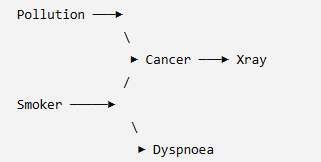

**Step 4: Define the Conditional Probability Distributions (CPDs)**

In [5]:
cpd_pollution = TabularCPD(
    variable='Pollution',
    variable_card=2,
    values=[[0.90], [0.10]]
)

Explanation

Pollution is a root node (it has no parent), so we assign its prior probabilities directly.

This means:
* There is a 90% chance of Low Pollution.
* There is a 10% chance of High Pollution.

In [6]:
cpd_smoker = TabularCPD(
    variable='Smoker',
    variable_card=2,
    values=[[0.70], [0.30]]
)

Explanation

Smoker is also a root node, so we assign prior probabilities.

This means:

*  70% of people are Non-Smokers.
*  30% of people are Smokers.

In [7]:
cpd_cancer = TabularCPD(
    variable='Cancer',
    variable_card=2,
    values=[
        [0.97, 0.90, 0.95, 0.75],  # No Cancer
        [0.03, 0.10, 0.05, 0.25]   # Cancer
    ],
    evidence=['Pollution', 'Smoker'],
    evidence_card=[2, 2]
)

Explanation

The probability of Cancer depends on Pollution and Smoking.

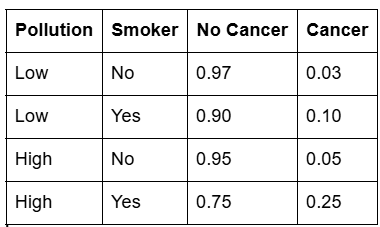

Observation: The highest probability of cancer (25%) occurs when a person is exposed to High Pollution and Smokes.

In [8]:
cpd_xray = TabularCPD(
    variable='Xray',
    variable_card=2,
    values=[
        [0.80, 0.10],  # Negative
        [0.20, 0.90]   # Positive
    ],
    evidence=['Cancer'],
    evidence_card=[2]
)

Explanation

The X-ray result depends only on whether the person has cancer.

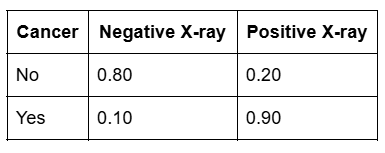

Observation:

* Cancer increases the probability of a Positive X-ray.
* A healthy person is more likely to have a Negative X-ray.

In [9]:
cpd_dyspnoea = TabularCPD(
    variable='Dyspnoea',
    variable_card=2,
    values=[
        [0.70, 0.35],  # No Dyspnoea
        [0.30, 0.65]   # Dyspnoea
    ],
    evidence=['Cancer'],
    evidence_card=[2]
)

Explanation

This CPD defines the probability of Dyspnoea (breathlessness) based on whether the person has Cancer.

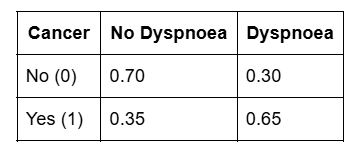



**Summary**

Pollution and Smoker are root nodes, so they use prior probabilities.

Cancer depends on Pollution and Smoker.

Xray depends on Cancer.

Dyspnoea depends on Cancer.

**Key Point**

In this step, we assign probabilities to every variable in the network. These probability tables (CPDs) allow the Bayesian Network to calculate the likelihood of different outcomes during inference.

**Step 6: Add the CPDs to the Bayesian Network**

In [11]:
# Add all CPDs to the Bayesian Network
model.add_cpds(
    cpd_pollution,
    cpd_smoker,
    cpd_cancer,
    cpd_xray,
    cpd_dyspnoea
)

Explanation

The add_cpds() function attaches each CPD to its corresponding node in the Bayesian Network.

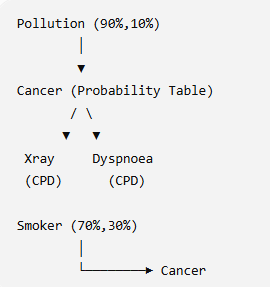


**Step 7: Validate the Bayesian Network**

The check_model() function checks whether:

* Every node has a CPD.
* The probabilities in each CPD sum to 1.
* The CPDs match the network structure.
* The Bayesian Network is valid.

In [12]:
# Check whether the Bayesian Network is valid
print(model.check_model())

True


Explanation

The check_model() function validates the entire Bayesian Network.

**Step 8: Create the Inference Engine**

In [13]:
# Import the inference algorithm
from pgmpy.inference import VariableElimination

# Create the inference engine
inference = VariableElimination(model)

Explanation:

**Import VariableElimination** - This imports the Variable Elimination algorithm, which is one of the most common methods used for probabilistic inference in Bayesian Networks.It calculates probabilities based on the network structure and CPDs.

**Create the Inference Object** - Here,model is our validated Bayesian Network.
VariableElimination(model) creates an inference engine for that model.
The inference engine is stored in the variable inference.

**Step 9: Perform Inference**

In [14]:
# Query 1: Probability of Cancer
# Evidence:
# Pollution = High (1)
# Smoker = Yes (1)

query1 = inference.query(
    variables=['Cancer'],
    evidence={
        'Pollution': 1,
        'Smoker': 1
    }
)

print(query1)

+-----------+---------------+
| Cancer    |   phi(Cancer) |
+===========+===============+
| Cancer(0) |        0.7500 |
+-----------+---------------+
| Cancer(1) |        0.2500 |
+-----------+---------------+


Explanation:This query uses the Variable Elimination inference algorithm to calculate the probability of Cancer. It takes High Pollution (Pollution = 1) and Smoking (Smoker = 1) as known evidence and computes the likelihood of the patient having or not having cancer. The result displays the probability distribution for the Cancer variable based on the given conditions.

In [15]:
# Query 2: Probability of Cancer
# Evidence:
# Xray = Positive (1)

query2 = inference.query(
    variables=['Cancer'],
    evidence={
        'Xray': 1
    }
)

print(query2)

+-----------+---------------+
| Cancer    |   phi(Cancer) |
+===========+===============+
| Cancer(0) |        0.7865 |
+-----------+---------------+
| Cancer(1) |        0.2135 |
+-----------+---------------+


Explanation:This query calculates the probability of Cancer using the Variable Elimination inference algorithm. It considers a Positive X-ray (Xray = 1) as the known evidence and updates the probability of the patient having or not having cancer. The output displays the probability distribution for the Cancer variable based on the X-ray result.

In [16]:
# Query 3: Probability of Dyspnoea
# Evidence:
# Cancer = Yes (1)

query3 = inference.query(
    variables=['Dyspnoea'],
    evidence={
        'Cancer': 1
    }
)

print(query3)

+-------------+-----------------+
| Dyspnoea    |   phi(Dyspnoea) |
+=============+=================+
| Dyspnoea(0) |          0.3500 |
+-------------+-----------------+
| Dyspnoea(1) |          0.6500 |
+-------------+-----------------+


Explanation:This query calculates the probability of Dyspnoea (breathlessness) using the Variable Elimination inference algorithm. It takes Cancer = Yes (Cancer = 1) as the known evidence and estimates the likelihood of the patient experiencing or not experiencing dyspnoea. The output displays the probability distribution for the Dyspnoea variable based on the presence of cancer.

**Step 12: Visualize the Bayesian Network**

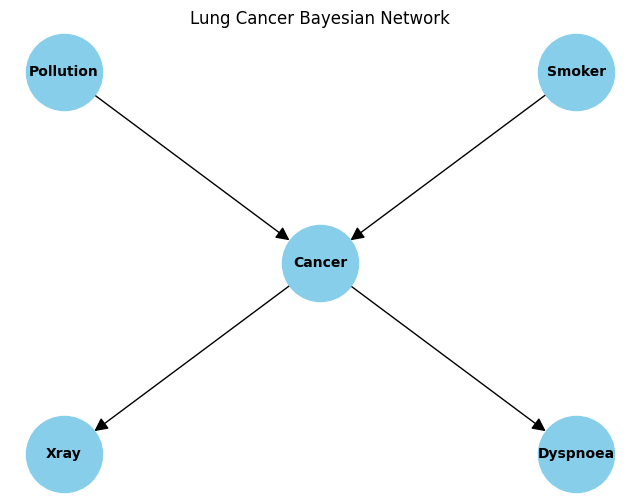

In [19]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph(model.edges())

plt.figure(figsize=(8,6))

pos = {
    "Pollution": (-1, 1),
    "Smoker": (1, 1),
    "Cancer": (0, 0),
    "Xray": (-1, -1),
    "Dyspnoea": (1, -1)
}

nx.draw_networkx(
    G,
    pos,
    node_color="skyblue",
    node_size=3000,
    font_size=10,
    font_weight="bold",
    arrows=True,
    arrowsize=20
)

plt.title("Lung Cancer Bayesian Network")
plt.axis("off")
plt.show()

Explanation:
Visualizing the Bayesian Network helps understand relationships between variables, verify the network structure, and clearly identify parent and child nodes. It also improves the presentation and interpretation of the model. NetworkX is used to create the graph, while Matplotlib is used to visualize it. The directed graph shows the dependencies among all variables.

**Conclusion**

In this experiment, we successfully implemented a Bayesian Network for Lung Cancer Diagnosis using the pgmpy library in Python.

The network modeled the probabilistic relationships among five variables:

* Pollution
* Smoker
* Cancer
* Xray
* Dyspnoea

We defined the network structure and created Conditional Probability Distributions (CPDs) for each variable. After validating the model using check_model(), we used the Variable Elimination algorithm to perform probabilistic inference.

The Bayesian Network was able to answer diagnostic questions such as:

* What is the probability of cancer given high pollution and smoking?
* What is the probability of cancer given a positive X-ray?
* What is the probability of dyspnoea if the patient has cancer?

Finally, we visualized the Bayesian Network to understand the dependencies between variables.

This experiment demonstrates how Bayesian Networks can be used for medical diagnosis under uncertainty, helping estimate disease probabilities from observed risk factors, symptoms, and test results.


## --MADE BY ASHWIN